In [144]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

FEATURES = ['Close', 'SMA10', 'SMA50', 'MACD', 'RSI', 'BB_Upper', 'BB_Mid', 'BB_Lower']
WINDOW = 30
HORIZON = 15

In [145]:
def get_user_input():
    ticker = input("Enter stock name (e.g. AAPL): ").strip().upper()
    start = input("Enter the start date of the analysis (in YYYY-MM-DD): ").strip()
    end = input("Enter the end date of the analysis (in YYYY-MM-DD): ").strip()
    timeframe = input("Enter timeframe (1d/1wk/1mo): ").strip().lower()

    return ticker, start, end, timeframe

In [146]:
def get_data(ticker,start,end,timeframe):
    df = yf.download(ticker, start=start, end=end, interval=timeframe)
    # if isinstance(df.columns, pd.MultiIndex):
    #     df.columns = df.columns.get_level_values(0)
    df = df[["Close","Volume"]]
    return df

In [147]:
def get_technical_indicators(df):
    df["SMA10"] = df["Close"].rolling(10).mean()

    delta = df["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    rs = gain/loss    
    df["RSI"] = 100-100/(1+rs)

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema12-ema26
    df["Signal"] = df["MACD"].ewm(span=9,adjust=False).mean()

    df['BB_Mid'] = df['Close'].rolling(20).mean()
    df['BB_Std'] = df['Close'].rolling(20).std()
    df['BB_Upper'] = df['BB_Mid'] + 2 * df['BB_Std']
    df['BB_Lower'] = df['BB_Mid'] - 2 * df['BB_Std']

    df['Return'] = df['Close'].pct_change()

    df.dropna(inplace=True)

    return df

In [148]:
def plot_price_indicators(df, ticker):
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    
    axes[0].plot(df.index, df['Close'], label='Close')
    axes[0].plot(df.index, df['SMA10'], label='SMA10')
    axes[0].set_title(f'{ticker} Close with SMA')

    axes[1].plot(df.index, df['Close'], label='Close')
    axes[1].plot(df.index, df['BB_Upper'], label='BB Upper', linestyle='dashed')
    axes[1].plot(df.index, df['BB_Lower'], label='BB Lower', linestyle='dashed')
    axes[1].set_title(f'{ticker} Close with Bollinger Bands')
    axes[1].legend()

    axes[2].plot(df.index, df['MACD'], label='MACD')
    axes[2].plot(df.index, df['Signal'], label='Signal')
    axes[2].set_title('MACD')
    axes[2].legend()

    axes[3].plot(df.index, df['RSI'], label='RSI', color='purple')
    axes[3].axhline(70, color='red', linestyle='dashed')
    axes[3].axhline(30, color='green', linestyle='dashed')
    axes[3].set_title('RSI')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

In [149]:
def create_sequences(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        # takes the 1st n(window) days as train set for x
        X.append(data[i:i + window])
        # take the next m (horizon) days as the actual predictions of the next days
        y.append(data[i + window:i + window + horizon, 0])
    return np.array(X), np.array(y)

In [150]:
def build_lstm(input_shape, horizon):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128,return_sequences= True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

In [151]:
class StockPredEnv(gym.Env):
    def __init__(self, obs_data, raw_returns, window, n_bins = 41, pct_range=0.05):
        super().__init__()
        self.data = obs_data
        self.raw_returns = raw_returns
        self.window = window
        # bins are like steps for a specific pct_range
        self.n_bins = n_bins
        self.bins = np.linspace(-pct_range,pct_range,n_bins)
        self.action_space = spaces.Discrete(n_bins)
        # low and high are set as the minmaxscaler or any other regulaizer gives value in this range
        # shape is reduced to 1D so that it can go to DQN
        # float32 used for efficient memory
        self.observation_space = spaces.Box(
            low=-10, high=10, shape=(window * obs_data.shape[1],), dtype=np.float32
        )
        # this will make the model start form day 20 for prediction
        self.ptr = window

        self.return_std = raw_returns[:, 0].std()

    def reset(self, seed=None,option = None):
        super().reset(seed=seed)
        self.ptr = self.window
        return self._get_obs(), {}  # returning empty dict for info while calling this function

    def _get_obs(self):
        return self.data[self.ptr - self.window:self.ptr].flatten().astype(np.float32)

    def step(self, action):
        predicted_return = self.bins[action]
        actual_return = self.raw_returns[self.ptr, 0]
        error = predicted_return - actual_return
        reward = -abs(error) / (self.return_std + 1e-8)
        self.ptr += 1
        terminated = self.ptr >= len(self.data) - 1
        return self._get_obs(), reward, terminated, False, {}

In [152]:
def rl_forecast(model, initial_window, horizon, bins, return_min, return_max):
    window = initial_window.copy()
    preds = []
    for _ in range(horizon):
        obs = window.flatten().astype(np.float32)
        action, _ = model.predict(obs, deterministic=True)
        predicted_return = bins[action]
        scaled_return = (predicted_return - return_min) / (return_max - return_min)
        new_row = window[-1].copy()
        new_row[0] = scaled_return
        window = np.vstack([window[1:], new_row])
        preds.append(predicted_return)
    return np.array(preds)

In [153]:
def compute_metrics(actual, predicted):
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [154]:
def returns_to_price(last_price, pred_returns):
    prices = []
    p = last_price
    for r in pred_returns:
        p = p * (1 + r)
        prices.append(p)
    return np.array(prices)

Enter stock name (e.g. AAPL):  AAPL
Enter the start date of the analysis (in YYYY-MM-DD):  2024-01-01
Enter the end date of the analysis (in YYYY-MM-DD):  2025-01-01
Enter timeframe (1d/1wk/1mo):  1d


[*********************100%***********************]  1 of 1 completed


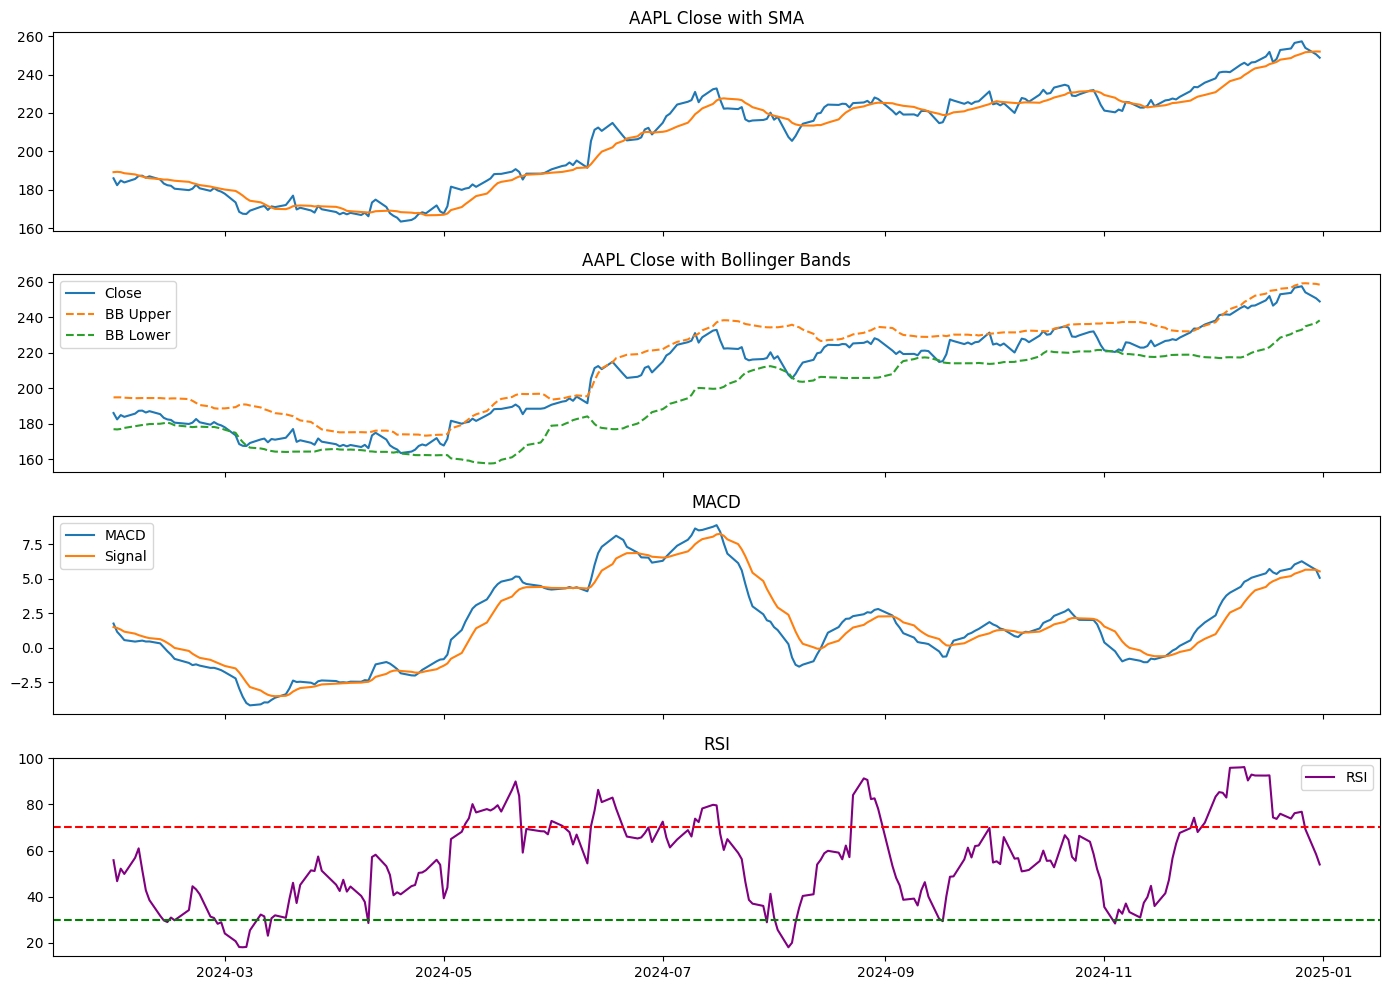

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - loss: 0.1624 - val_loss: 0.0903
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.1005 - val_loss: 0.0484
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0709 - val_loss: 0.0367
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0570 - val_loss: 0.0294
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0448 - val_loss: 0.0224
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0417 - val_loss: 0.0203
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0341 - val_loss: 0.0151
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0329 - val_loss: 0.0153
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0314 - val_loss: 0.0123
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0283 - val_loss: 0.0115
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0259 - val_loss: 0.0116
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0252 - val_loss: 0.0115


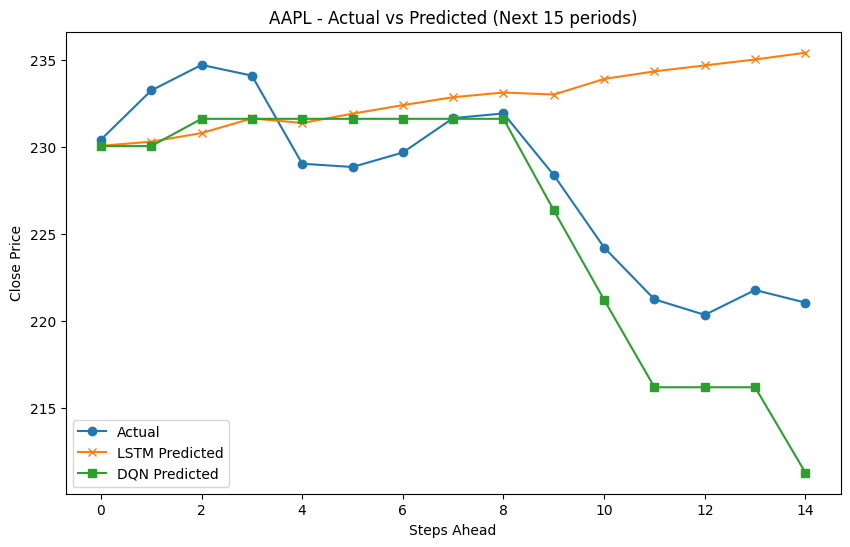

In [163]:
def main():
    ticker, start, end, timeframe = get_user_input()
    df = get_data(ticker,start,end,timeframe)
    df = get_technical_indicators(df)
    length_of_dataset = len(df)
    plot_price_indicators(df,ticker)
    
    FEATURES = ['Return', 'SMA10', 'MACD', 'RSI', 'BB_Upper', 'BB_Mid', 'BB_Lower','Volume']
    feature_data = df[FEATURES].values
    # We covert the features through mix max scaler so that all the features comes in similar magnitude.
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(feature_data)

    X, y = create_sequences(scaled, WINDOW, HORIZON)
    split = int(len(X)*0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Prediction through lstm architecture

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    lstm_model = build_lstm((WINDOW, len(FEATURES)), HORIZON)
    lstm_model.fit(X_train, y_train, epochs= 50, batch_size= 32, validation_split= 0.1, verbose= 1, callbacks=[early_stop])
    lstm_pred_scaled = lstm_model.predict(X_test)[0]

    def inverse_return(col_values):
        dummy = np.zeros((len(col_values), len(FEATURES)))
        dummy[:, 0] = col_values
        return scaler.inverse_transform(dummy)[:, 0]

    lstm_pred_returns = inverse_return(lstm_pred_scaled)
    actual_returns = inverse_return(y_test[0])
    
    test_start_idx = split + WINDOW
    last_actual_price = df['Close'].iloc[test_start_idx - 1]
    actual = returns_to_price(last_actual_price, actual_returns)
    lstm_pred = returns_to_price(last_actual_price, lstm_pred_returns)

    # Prediction through RL architecture
    pct_range = max(abs(np.percentile(feature_data[:, 0], 1)), abs(np.percentile(feature_data[:, 0], 99))) * 1.1
    env = StockPredEnv(scaled[:split + WINDOW], feature_data[:split + WINDOW], WINDOW, pct_range=pct_range)
    dqn_model = DQN('MlpPolicy', env, verbose=1, learning_rate=3e-4,
                     buffer_size=length_of_dataset*10, learning_starts=500, batch_size=64)
    dqn_model.learn(total_timesteps=length_of_dataset*50)

    initial_window = scaled[split:split + WINDOW]
    return_min = feature_data[:, 0].min()
    return_max = feature_data[:, 0].max()
    rl_pred_returns = rl_forecast(dqn_model, initial_window, HORIZON, env.bins, return_min, return_max)
    rl_pred = returns_to_price(last_actual_price, rl_pred_returns)

    lstm_metrics = compute_metrics(actual, lstm_pred)
    rl_metrics = compute_metrics(actual, rl_pred)

    print("LSTM Metrics:", lstm_metrics)
    print("DQN Metrics:", rl_metrics)

    plt.figure(figsize=(10, 6))
    plt.plot(range(HORIZON), actual, label='Actual', marker='o')
    plt.plot(range(HORIZON), lstm_pred, label='LSTM Predicted', marker='x')
    plt.plot(range(HORIZON), rl_pred, label='DQN Predicted', marker='s')
    plt.title(f'{ticker} - Actual vs Predicted (Next {HORIZON} periods)')
    plt.xlabel('Steps Ahead')
    plt.ylabel('Close Price')
    plt.legend()
    plt.savefig('prediction_comparison.png')
    plt.show()

if __name__ == '__main__':
    main()